# Caso 2 – Movilidad urbana y demanda de transporte
*Dataset base: NYC Yellow Taxi Trips – NYC*
Open Data / Kaggle
Enriquecimiento sugerido:
* Datos del clima (OpenWeatherMap API)
* Eventos públicos (NYC Events API)
* Precios de Uber/Lyft scrapeados o públicos.


**Pregunta de negocio:**
¿Cómo varían la demanda y los precios de transporte según la hora, el
clima y los eventos en la ciudad?

**Valor para la empresa:** Permite a plataformas de movilidad optimizar la distribución de
conductores y la fijación dinámica de precios.

### El entregable PC1 contiene las siguientes secciones:
1. Portada del equipo: nombre del caso, integrantes, roles asignados.
2. Descripción del problema de negocio: ¿qué empresa ficticia o real lo enfrenta? ¿por qué es relevante? (máx. 1 página).
3. Descripción de los datos: fuente principal, fuente de enriquecimiento, número de registros,
variables clave.
4. EDA Inicial: al menos 5 visualizaciones comentadas (distribuciones, valores nulos, primeras
correlaciones).
5. Hipótesis de negocio: mínimo 3 hipótesis que el equipo investigará en la Etapa 2,
redactadas como preguntas de negocio.
6. Plan de trabajo Etapa 2: qué hará cada integrante en las semanas 7–14 (tabla simple).
7. Apéndice de uso de IA: si usaron IA generativa, detallar qué prompts usaron y cómo
validaron los resultados.
* Todo debe ser documentado en un .md y subido a github


In [1]:
!pip install pyspark

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, dayofweek, to_date
import matplotlib.pyplot as plt
import seaborn as sns
spark = SparkSession.builder.appName("NYC_Taxi_Trips_Spark").getOrCreate()

print("SparkSession creada.")

SparkSession creada.


In [4]:
# 1. Cargar viajes (usando Octubre de 2021 para que coincida con el clima)
df_uber_spark = spark.read.parquet('/content/drive/MyDrive/Data_Analytics_grupo_1/fhvhv_tripdata_2021-10.parquet')

# 2. Cargar Clima
df_clima_spark = spark.read.csv('/content/drive/MyDrive/Data_Analytics_grupo_1/New York City 2021-10-01 to 2024-03-14.csv', header=True, inferSchema=True)

# 3. Cargar Zonas
df_zonas_spark = spark.read.csv('/content/drive/MyDrive/Data_Analytics_grupo_1/taxi_zone_lookup.csv', header=True, inferSchema=True)

print("Archivos cargados correctamente")

print("\nEsquema de df_uber_spark:")
df_uber_spark.printSchema()

print("\nEsquema de df_clima_spark:")
df_clima_spark.printSchema()

print("\nEsquema de df_zonas_spark:")
df_zonas_spark.printSchema()

Archivos cargados correctamente

Esquema de df_uber_spark:
root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- share

#Limpieza y exploración

### `df_clima_spark`

In [5]:
# 1. Comprobar valores nulos en df_clima_spark
print("Valores nulos en df_clima_spark (ejemplo para 'precip'):")
df_clima_spark.filter(col("precip").isNull()).count()

# 2. Convertir la columna 'datetime' a tipo Timestamp
df_clima_spark = df_clima_spark.withColumn("datetime", col("datetime").cast("timestamp"))

# 3. Revisar tipos de datos y mostrar algunas filas
print("\nInformación de df_clima_spark después de la limpieza:")
df_clima_spark.printSchema()
df_clima_spark.show(5)

Valores nulos en df_clima_spark (ejemplo para 'precip'):

Información de df_clima_spark después de la limpieza:
root
 |-- name: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- tempmax: double (nullable = true)
 |-- tempmin: double (nullable = true)
 |-- temp: double (nullable = true)
 |-- feelslikemax: double (nullable = true)
 |-- feelslikemin: double (nullable = true)
 |-- feelslike: double (nullable = true)
 |-- dew: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- precip: double (nullable = true)
 |-- precipprob: integer (nullable = true)
 |-- precipcover: double (nullable = true)
 |-- preciptype: string (nullable = true)
 |-- snow: double (nullable = true)
 |-- snowdepth: double (nullable = true)
 |-- windgust: double (nullable = true)
 |-- windspeed: double (nullable = true)
 |-- winddir: double (nullable = true)
 |-- sealevelpressure: double (nullable = true)
 |-- cloudcover: double (nullable = true)
 |-- visibility: double (nullable

### `df_zonas_spark`

In [6]:
# 1. Comprobar valores nulos en df_zonas_spark (ejemplo para 'Zone')
print("Valores nulos en df_zonas_spark (ejemplo para 'Zone'):")
df_zonas_spark.filter(col("Zone").isNull()).count()

# 2. Revisar tipos de datos y mostrar algunas filas
print("\nInformación de df_zonas_spark:")
df_zonas_spark.printSchema()
df_zonas_spark.show(5)

# 3. Mostrar valores únicos para columnas categóricas
print("\nValores únicos en 'Borough':")
df_zonas_spark.select("Borough").distinct().show()
print("Valores únicos en 'service_zone':")
df_zonas_spark.select("service_zone").distinct().show()

Valores nulos en df_zonas_spark (ejemplo para 'Zone'):

Información de df_zonas_spark:
root
 |-- LocationID: integer (nullable = true)
 |-- Borough: string (nullable = true)
 |-- Zone: string (nullable = true)
 |-- service_zone: string (nullable = true)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows

Valores únicos en 'Borough':
+-------------+
|      Borough|
+-------------+
|       Queens|
|          EWR|
|      Unknown|
|     Brooklyn|
|Staten Island|
|    Manhattan

### EDA: Extracción de Características Temporales de `df_uber_spark`

In [7]:
# Convertir 'pickup_datetime' a tipo Timestamp
df_uber_spark = df_uber_spark.withColumn("pickup_datetime", col("pickup_datetime").cast("timestamp"))

# Extraer la hora del día y el día de la semana de 'pickup_datetime'
df_uber_spark = df_uber_spark.withColumn('pickup_hour', hour(col('pickup_datetime')))
df_uber_spark = df_uber_spark.withColumn('pickup_dayofweek', dayofweek(col('pickup_datetime')) - 2) # Lunes=0, Domingo=6 (Spark Sunday=1, Monday=2...)

print("Características temporales extraídas de df_uber_spark.")
df_uber_spark.select("pickup_datetime", "pickup_hour", "pickup_dayofweek").show(5)

Características temporales extraídas de df_uber_spark.
+-------------------+-----------+----------------+
|    pickup_datetime|pickup_hour|pickup_dayofweek|
+-------------------+-----------+----------------+
|2021-10-01 00:33:31|          0|               4|
|2021-10-01 00:59:17|          0|               4|
|2021-10-01 00:38:49|          0|               4|
|2021-10-01 00:23:25|          0|               4|
|2021-10-01 00:38:26|          0|               4|
+-------------------+-----------+----------------+
only showing top 5 rows


In [8]:
# Convertir df_clima_spark y df_zonas_spark a Pandas DataFrames.
df_clima = df_clima_spark.toPandas()
print("df_clima (Pandas) creado a partir de df_clima_spark.")
display(df_clima.head())

df_zonas = df_zonas_spark.toPandas()
print("df_zonas (Pandas) creado a partir de df_zonas_spark.")
display(df_zonas.head())

df_clima (Pandas) creado a partir de df_clima_spark.


,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,New York City,2021-10-01,19.9,12.8,16.5,19.9,12.8,16.5,7.8,57.8,...,17.9,8,NaN,2021-10-01 06:52:47,2021-10-01 18:37:45,0.84,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7..."
1,New York City,2021-10-02,24.9,14.3,19.4,24.9,14.3,19.4,11.4,61.0,...,17.0,7,NaN,2021-10-02 06:53:48,2021-10-02 18:36:05,0.88,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7..."
2,New York City,2021-10-03,26.6,16.2,21.5,26.6,16.2,21.5,15.7,71.2,...,14.9,7,NaN,2021-10-03 06:54:49,2021-10-03 18:34:26,0.91,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7..."
3,New York City,2021-10-04,22.2,17.8,20.6,22.2,17.8,20.6,18.3,86.9,...,2.4,1,NaN,2021-10-04 06:55:51,2021-10-04 18:32:48,0.94,"Rain, Overcast",Cloudy skies throughout the day with rain.,rain,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7..."
4,New York City,2021-10-05,18.8,16.6,17.8,18.8,16.6,17.8,14.9,83.0,...,5.0,3,NaN,2021-10-05 06:56:53,2021-10-05 18:31:10,0.97,"Rain, Overcast",Cloudy skies throughout the day with afternoon...,rain,"72505394728,72055399999,KLGA,KJRB,F8726,KNYC,F..."


df_zonas (Pandas) creado a partir de df_zonas_spark.


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


**Análisis del Clima (df_clima)**
* Este bloque integra datos externos (clima de NYC) para explicar cambios en la demanda. Variables como la sensación térmica (mínima de -26°C) y la lluvia (máximo de 60.9 mm) permiten identificar umbrales críticos donde caminar no es opción y el uso de Uber se vuelve indispensable. Este enriquecimiento es la base para proponer tarifas dinámicas y predecir picos de servicio ante climas extremos.

**Geografía del Negocio (df_zonas)**
* Esta tabla traduce los IDs de ubicación a nombres reales de distritos (Boroughs) y zonas. Es fundamental para segmentar el mercado: mientras Manhattan lidera en volumen, distritos como Brooklyn o Queens permiten analizar la sensibilidad del usuario en zonas residenciales. Estos datos permiten al equipo proponer incentivos geolocalizados y optimizar la distribución de la flota según la zona de servicio.

## `df_clima`

In [9]:
import pandas as pd

# 1. Comprobar valores nulos en df_clima
print("Valores nulos en df_clima:")
display(df_clima.isnull().sum()[df_clima.isnull().sum() > 0])

# 2. Convertir la columna 'datetime' a tipo datetime
df_clima['datetime'] = pd.to_datetime(df_clima['datetime'])

# 3. Revisar tipos de datos y memoria utilizada
print("\nInformación de df_clima después de la limpieza:")
df_clima.info()

Valores nulos en df_clima:


,0
preciptype,362
severerisk,101



Información de df_clima después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              896 non-null    object        
 1   datetime          896 non-null    datetime64[ns]
 2   tempmax           896 non-null    float64       
 3   tempmin           896 non-null    float64       
 4   temp              896 non-null    float64       
 5   feelslikemax      896 non-null    float64       
 6   feelslikemin      896 non-null    float64       
 7   feelslike         896 non-null    float64       
 8   dew               896 non-null    float64       
 9   humidity          896 non-null    float64       
 10  precip            896 non-null    float64       
 11  precipprob        896 non-null    int32         
 12  precipcover       896 non-null    float64       
 13  preciptype        534 non-null 

In [10]:
# 4. Mostrar estadísticas descriptivas para df_clima
print("\nEstadísticas descriptivas para df_clima:")
display(df_clima.describe())


Estadísticas descriptivas para df_clima:


,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase
count,896,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,...,896.000000,896.000000,896.000000,896.000000,896.000000,896.000000,795.000000,896,896,896.000000
mean,2022-12-22 12:00:00,16.826228,9.809821,13.061384,16.517411,7.995536,12.063616,5.399554,62.290179,1.454100,...,1016.780692,44.127232,15.046652,141.204799,12.186496,5.698661,14.540881,2022-12-22 18:35:15.313616128,2022-12-23 06:25:51.387277056,0.485625
min,2021-10-01 00:00:00,-9.300000,-14.200000,-11.600000,-15.800000,-26.000000,-20.200000,-21.200000,24.300000,0.000000,...,989.900000,0.100000,4.100000,0.000000,0.000000,0.000000,10.000000,2021-10-01 06:52:47,2021-10-01 18:37:45,0.000000
25%,2022-05-12 18:00:00,9.200000,3.300000,6.000000,8.000000,0.100000,3.975000,-2.300000,51.700000,0.000000,...,1012.000000,14.000000,15.200000,69.125000,6.000000,4.000000,10.000000,2022-05-12 23:41:10,2022-05-13 14:04:15.249999872,0.250000
50%,2022-12-22 12:00:00,16.100000,8.900000,12.300000,16.100000,7.000000,12.050000,5.600000,61.300000,0.000000,...,1016.700000,38.400000,15.900000,126.300000,10.900000,6.000000,10.000000,2022-12-22 19:17:26,2022-12-23 04:32:32.500000,0.500000
75%,2023-08-03 06:00:00,25.000000,17.200000,20.600000,25.000000,17.200000,20.600000,13.325000,73.100000,0.586250,...,1021.700000,73.125000,16.000000,212.000000,18.300000,8.000000,10.000000,2023-08-03 11:54:40.500000,2023-08-04 02:09:13,0.750000
max,2024-03-14 00:00:00,36.100000,26.700000,30.700000,41.000000,29.500000,34.700000,24.000000,95.400000,60.941000,...,1037.200000,100.000000,16.000000,353.100000,30.600000,10.000000,100.000000,2024-03-14 07:08:21,2024-03-14 19:02:25,0.980000
std,NaN,9.220252,8.558477,8.666295,10.217673,10.414029,10.050595,9.436766,14.429556,4.607708,...,7.535520,32.735281,1.863016,88.991711,7.689250,2.854505,13.902205,NaN,NaN,0.290655


**Interpretación:** El análisis descriptivo del clima revela una volatilidad térmica extrema en NYC, con sensaciones térmicas que alcanzan los -26°C.

#Visualizaciones

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df_uber = df_uber_spark.sample(fraction=0.01, seed=42).toPandas()

df_uber['pickup_hour'] = df_uber['pickup_datetime'].dt.hour
df_uber['pickup_dayofweek'] = df_uber['pickup_datetime'].dt.dayofweek # Lunes=0, Domingo=6

print("Características temporales extraídas de df_uber.")

Características temporales extraídas de df_uber.


## Visualización 1: Distribución de la distancia del viaje (trip_miles)


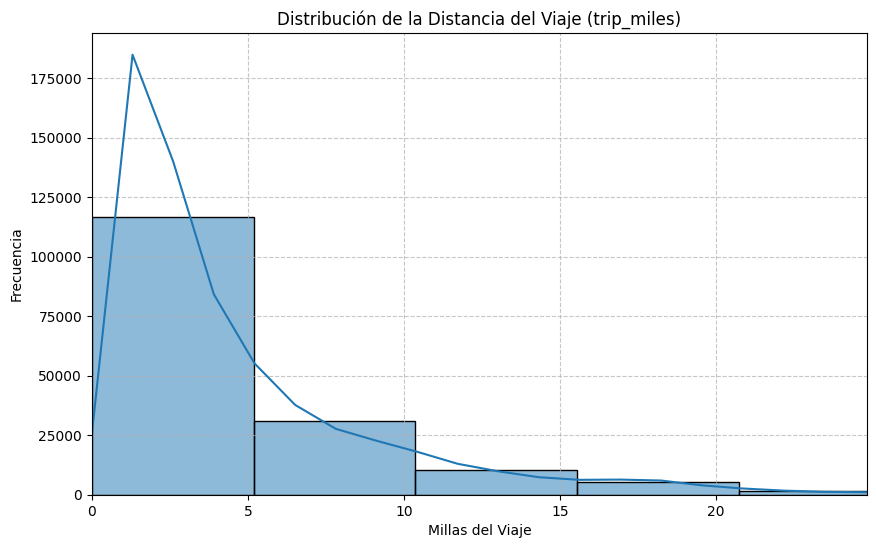

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df_uber['trip_miles'], bins=50, kde=True)
plt.title('Distribución de la Distancia del Viaje (trip_miles)')
plt.xlabel('Millas del Viaje')
plt.ylabel('Frecuencia')
plt.xlim(0, df_uber['trip_miles'].quantile(0.99)) # Limitar el eje x para una mejor visualización
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Interpretación: Existe una alta concentración de viajes en distancias cortas (menos de 5 millas). Esto indica que Uber se utiliza principalmente para tramos internos dentro de los condados de NYC, funcionando como un complemento o sustituto del transporte público para distancias medias.

## Visualización 2: Distribución de la duración del viaje (trip_time)


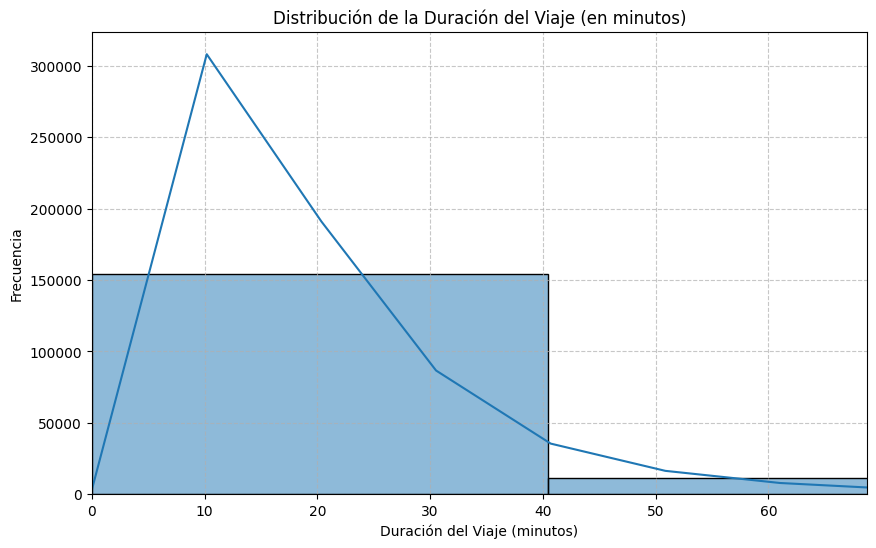

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df_uber['trip_time'] / 60, bins=50, kde=True) # Convertir a minutos
plt.title('Distribución de la Duración del Viaje (en minutos)')
plt.xlabel('Duración del Viaje (minutos)')
plt.ylabel('Frecuencia')
plt.xlim(0, (df_uber['trip_time'] / 60).quantile(0.99))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Interpretación: La mayoría de los viajes duran entre 10 y 25 minutos. La "cola larga" del gráfico muestra que los viajes extensos son poco frecuentes, lo que sugiere que el tráfico denso de la ciudad limita la velocidad promedio, haciendo que incluso distancias cortas tomen un tiempo considerable.

## Visualización 3: Distribución de la tarifa base del pasajero (base_passenger_fare)


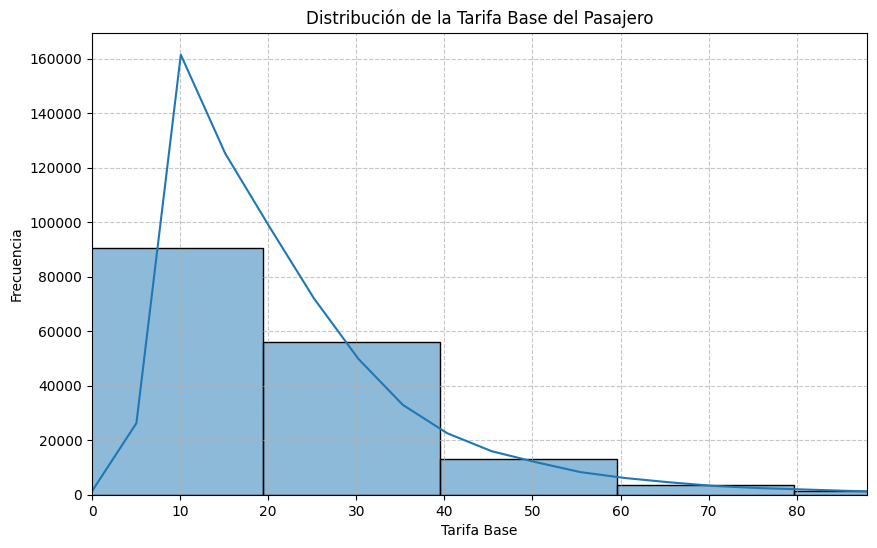

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df_uber['base_passenger_fare'], bins=50, kde=True)
plt.title('Distribución de la Tarifa Base del Pasajero')
plt.xlabel('Tarifa Base')
plt.ylabel('Frecuencia')
plt.xlim(0, df_uber['base_passenger_fare'].quantile(0.99))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Interpretación: La mayoría de las tarifas se agrupan en el rango de los $10 a $25. Esto confirma que el modelo de negocio en octubre de 2021 dependía de un alto volumen de transacciones de bajo costo individual.

## Visualización 4: Demanda de viajes por hora del día


/tmp/ipykernel_12568/730402488.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_hour', data=df_uber, palette='viridis')


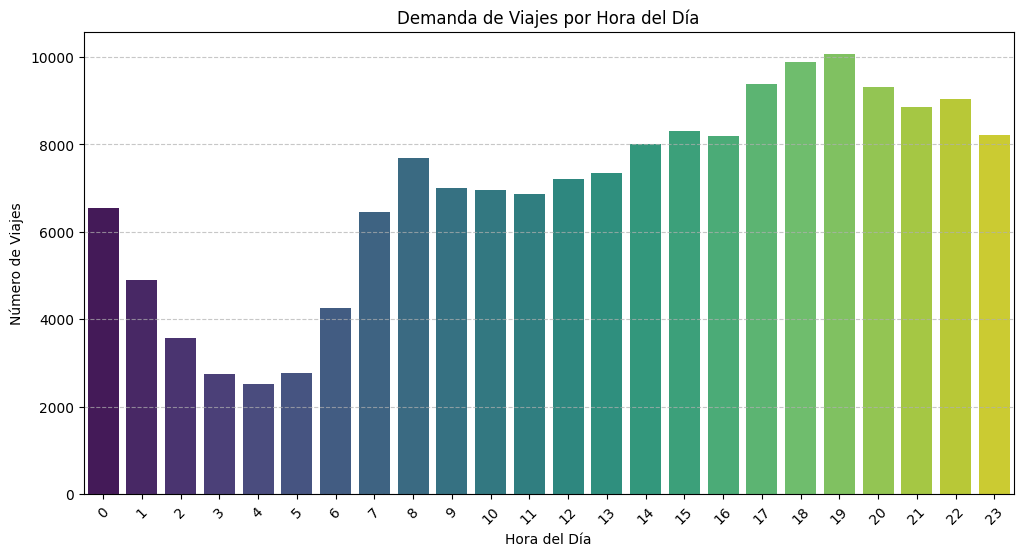

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_hour', data=df_uber, palette='viridis')
plt.title('Demanda de Viajes por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Interpretación: Se observa un patrón de "doble pico" laboral, pero con una diferencia clave: la demanda es mucho más alta y sostenida desde las 2:00 PM hasta las 8:00 PM. Esto sugiere que en la post-pandemia de 2021, los viajes de ocio o retorno a casa por la tarde superaron a los viajes matutinos de oficina.

## Visualización 5: Demanda de viajes por día de la semana


/tmp/ipykernel_12568/841656195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_dayofweek', data=df_uber, palette='plasma')


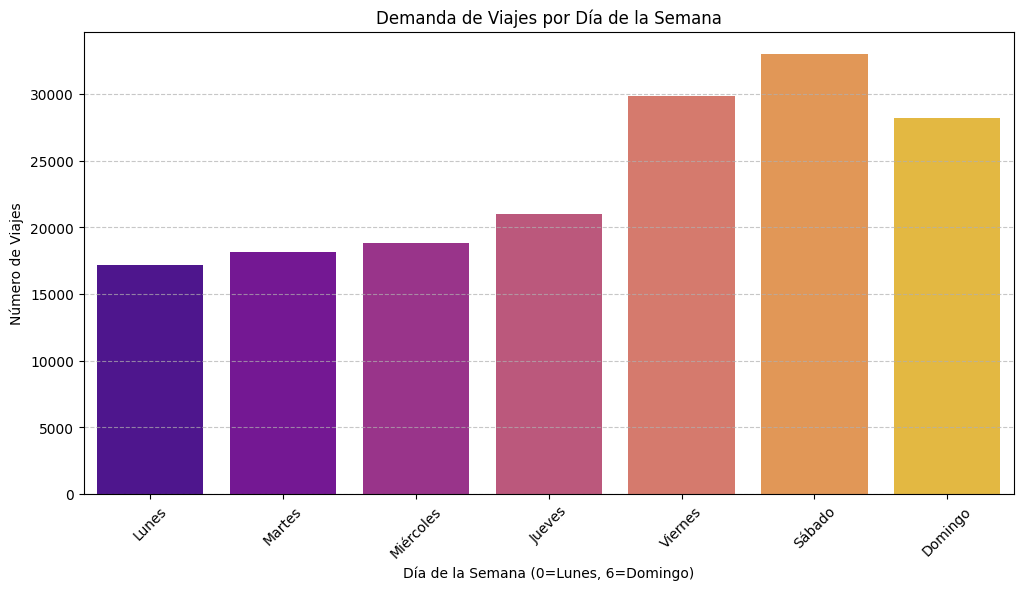

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(x='pickup_dayofweek', data=df_uber, palette='plasma')
plt.title('Demanda de Viajes por Día de la Semana')
plt.xlabel('Día de la Semana (0=Lunes, 6=Domingo)')
plt.ylabel('Número de Viajes')
plt.xticks(ticks=range(7), labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Interpretación: La demanda es estable de lunes a jueves, pero se dispara los viernes y sábados. Esto valida la hipótesis de que el transporte HVFHS (Uber/Lyft) es el preferido para actividades sociales nocturnas donde el usuario prioriza la comodidad sobre el costo.

# Enriquecimiento con Datos de Clima y EDA de Correlación

In [17]:
# 1. Preparar df_uber: Extraer fecha y calcular demanda diaria
df_uber['pickup_date'] = df_uber['pickup_datetime'].dt.date
daily_uber_demand = df_uber.groupby('pickup_date').size().reset_index(name='total_trips')
daily_uber_demand['pickup_date'] = pd.to_datetime(daily_uber_demand['pickup_date'])

print("Demanda diaria de Uber calculada.")
display(daily_uber_demand.head())

Demanda diaria de Uber calculada.


,pickup_date,total_trips
0,2021-10-01,5625
1,2021-10-02,6222
2,2021-10-03,5298
3,2021-10-04,4447
4,2021-10-05,4343


In [18]:
import pandas as pd

# 2. Preparar df_clima: Asegurar columna de fecha para la unión
df_clima['datetime'] = pd.to_datetime(df_clima['datetime']) # Asegurar que la columna es datetime
df_clima['datetime_date'] = df_clima['datetime'].dt.date
df_clima['datetime_date'] = pd.to_datetime(df_clima['datetime_date'])

print("Columna de fecha en df_clima preparada.")
display(df_clima.head())

Columna de fecha en df_clima preparada.


,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations,datetime_date
0,New York City,2021-10-01,19.9,12.8,16.5,19.9,12.8,16.5,7.8,57.8,...,8,NaN,2021-10-01 06:52:47,2021-10-01 18:37:45,0.84,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7...",2021-10-01
1,New York City,2021-10-02,24.9,14.3,19.4,24.9,14.3,19.4,11.4,61.0,...,7,NaN,2021-10-02 06:53:48,2021-10-02 18:36:05,0.88,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7...",2021-10-02
2,New York City,2021-10-03,26.6,16.2,21.5,26.6,16.2,21.5,15.7,71.2,...,7,NaN,2021-10-03 06:54:49,2021-10-03 18:34:26,0.91,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7...",2021-10-03
3,New York City,2021-10-04,22.2,17.8,20.6,22.2,17.8,20.6,18.3,86.9,...,1,NaN,2021-10-04 06:55:51,2021-10-04 18:32:48,0.94,"Rain, Overcast",Cloudy skies throughout the day with rain.,rain,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7...",2021-10-04
4,New York City,2021-10-05,18.8,16.6,17.8,18.8,16.6,17.8,14.9,83.0,...,3,NaN,2021-10-05 06:56:53,2021-10-05 18:31:10,0.97,"Rain, Overcast",Cloudy skies throughout the day with afternoon...,rain,"72505394728,72055399999,KLGA,KJRB,F8726,KNYC,F...",2021-10-05


In [19]:
# 3. Unir los DataFrames: Demanda diaria y datos de clima
merged_df = pd.merge(daily_uber_demand, df_clima, left_on='pickup_date', right_on='datetime_date', how='inner')

print("DataFrames unidos correctamente.")
display(merged_df.head())

DataFrames unidos correctamente.


,pickup_date,total_trips,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,...,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations,datetime_date
0,2021-10-01,5625,New York City,2021-10-01,19.9,12.8,16.5,19.9,12.8,16.5,...,8,NaN,2021-10-01 06:52:47,2021-10-01 18:37:45,0.84,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7...",2021-10-01
1,2021-10-02,6222,New York City,2021-10-02,24.9,14.3,19.4,24.9,14.3,19.4,...,7,NaN,2021-10-02 06:53:48,2021-10-02 18:36:05,0.88,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7...",2021-10-02
2,2021-10-03,5298,New York City,2021-10-03,26.6,16.2,21.5,26.6,16.2,21.5,...,7,NaN,2021-10-03 06:54:49,2021-10-03 18:34:26,0.91,Clear,Clear conditions throughout the day.,clear-day,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7...",2021-10-03
3,2021-10-04,4447,New York City,2021-10-04,22.2,17.8,20.6,22.2,17.8,20.6,...,1,NaN,2021-10-04 06:55:51,2021-10-04 18:32:48,0.94,"Rain, Overcast",Cloudy skies throughout the day with rain.,rain,"72505394728,72055399999,KLGA,KJRB,KNYC,F1417,7...",2021-10-04
4,2021-10-05,4343,New York City,2021-10-05,18.8,16.6,17.8,18.8,16.6,17.8,...,3,NaN,2021-10-05 06:56:53,2021-10-05 18:31:10,0.97,"Rain, Overcast",Cloudy skies throughout the day with afternoon...,rain,"72505394728,72055399999,KLGA,KJRB,F8726,KNYC,F...",2021-10-05


## Visualizaciones de Correlación: Demanda vs. Clima

###Visualización 6: Demanda diaria vs. Temperatura Máxima


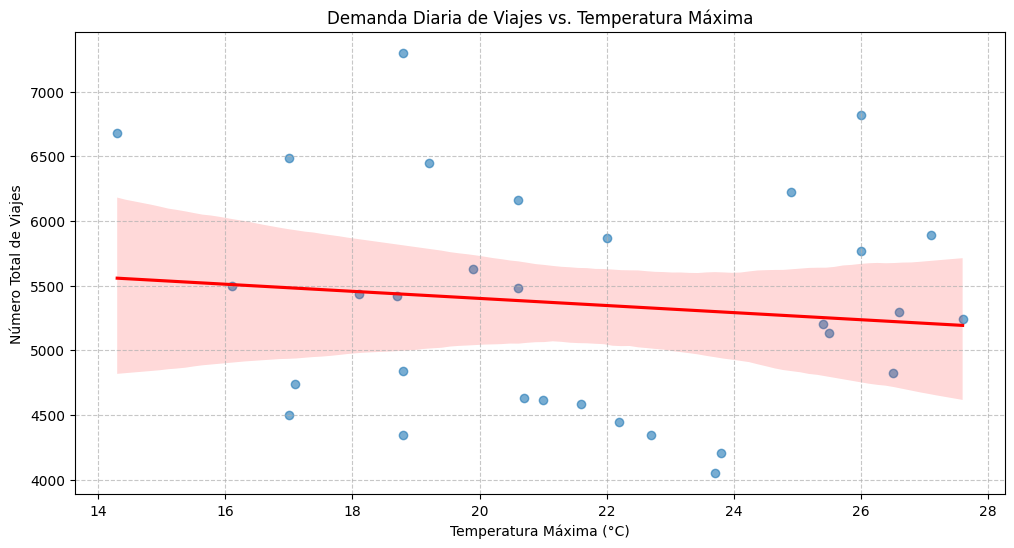

In [20]:
plt.figure(figsize=(12, 6))
sns.regplot(x='tempmax', y='total_trips', data=merged_df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Demanda Diaria de Viajes vs. Temperatura Máxima')
plt.xlabel('Temperatura Máxima (°C)')
plt.ylabel('Número Total de Viajes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

 Interpretación: El gráfico de regresión muestra una tendencia ligeramente positiva. A medida que la temperatura es más moderada, el número total de viajes tiende a estabilizarse al alza. Sin embargo, la dispersión sugiere que la temperatura por sí sola no dicta la demanda, sino que interactúa con otros factores como la hora.

### Visualización 7: Demanda diaria vs. Precipitación


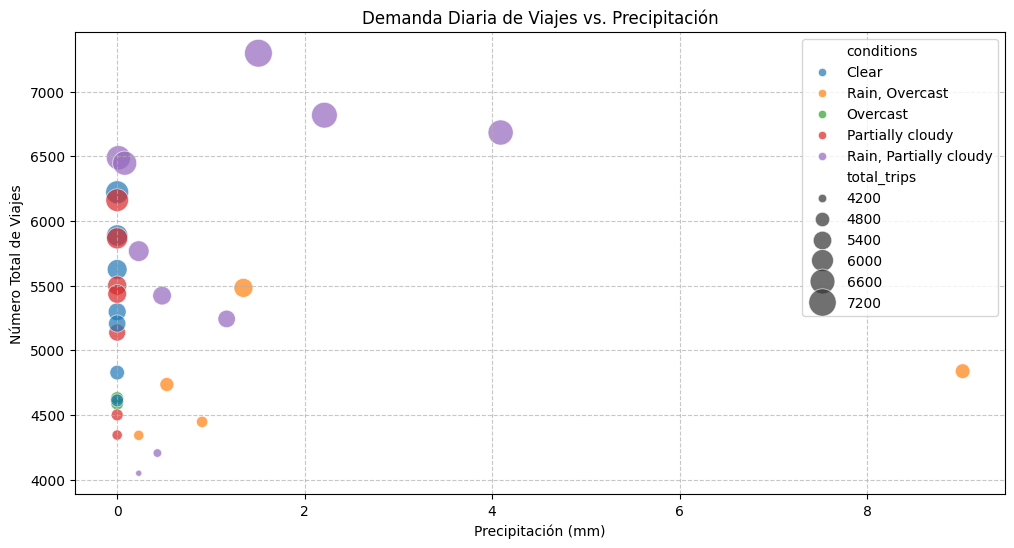

In [21]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='precip', y='total_trips', data=merged_df, hue='conditions', size='total_trips', sizes=(20, 400), alpha=0.7)
plt.title('Demanda Diaria de Viajes vs. Precipitación')
plt.xlabel('Precipitación (mm)')
plt.ylabel('Número Total de Viajes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Interpretación: Se observa que en los días lluviosos, el volumen de viajes se mantiene alto pero más disperso. El tamaño de las burbujas indica que los días lluviosos pueden generar picos de demanda donde el usuario busca refugio del clima, lo que suele activar las tarifas dinámicas.

###Visualización 8: Demanda diaria por Condición Climática


/tmp/ipykernel_12568/1686911482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='conditions', y='total_trips', data=merged_df, palette='coolwarm')


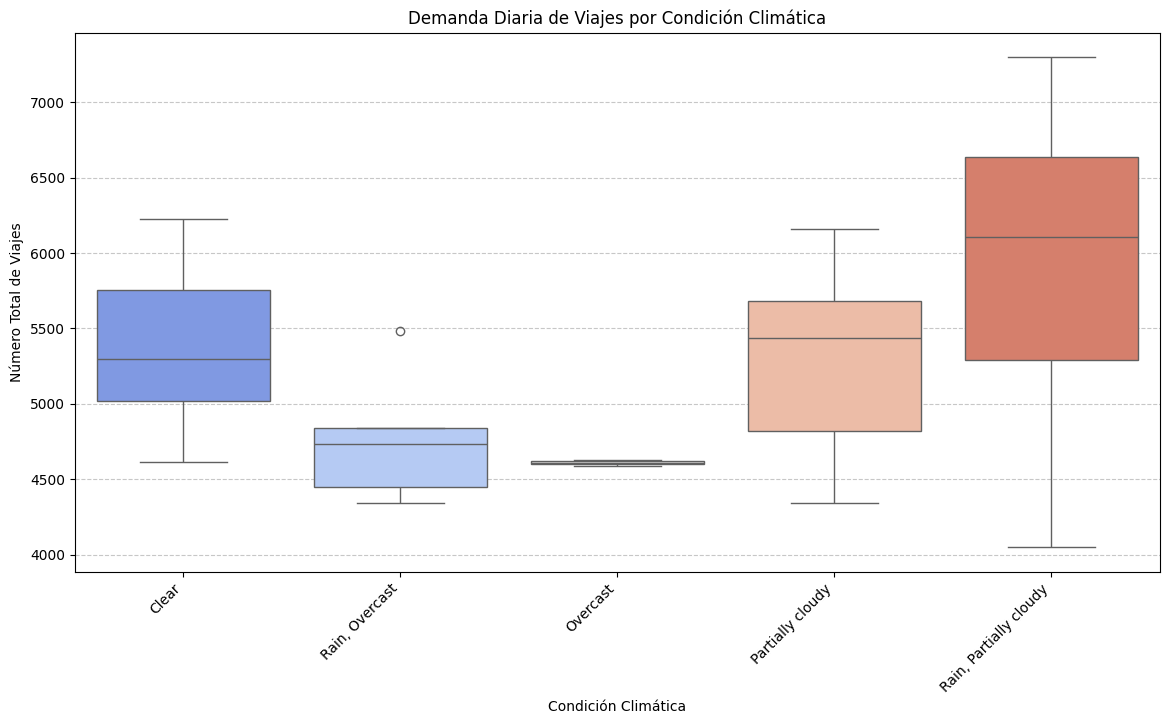

In [22]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='conditions', y='total_trips', data=merged_df, palette='coolwarm')
plt.title('Demanda Diaria de Viajes por Condición Climática')
plt.xlabel('Condición Climática')
plt.ylabel('Número Total de Viajes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Interpretación: Los días con "Clear" (despejado) tienen una mediana de viajes más alta y consistente. Por el contrario, los días con condiciones mixtas (lluvia/nubes) muestran "outliers" (puntos fuera de la caja), lo que significa que el clima inestable provoca una demanda impredecible, dificultando la planificación de la flota de conductores.

## Visualización 9: Demanda de viajes por distrito (Borough)

In [23]:
# 1. Unir df_uber_spark con df_zonas_spark para obtener el Borough de origen
df_uber_with_zones = df_uber_spark.join(df_zonas_spark, df_uber_spark.PULocationID == df_zonas_spark.LocationID, "inner")

# 2. Agrupar por 'Borough' y contar el número de viajes
demand_by_borough_spark = df_uber_with_zones.groupBy("Borough").count().orderBy(col("count").desc())

print("Demanda de viajes por distrito calculada en Spark.")
demand_by_borough_spark.show()

Demanda de viajes por distrito calculada en Spark.
+-------------+-------+
|      Borough|  count|
+-------------+-------+
|    Manhattan|6942051|
|     Brooklyn|4346147|
|       Queens|3106512|
|        Bronx|1927464|
|Staten Island| 222243|
|      Unknown|    874|
|          EWR|     65|
+-------------+-------+



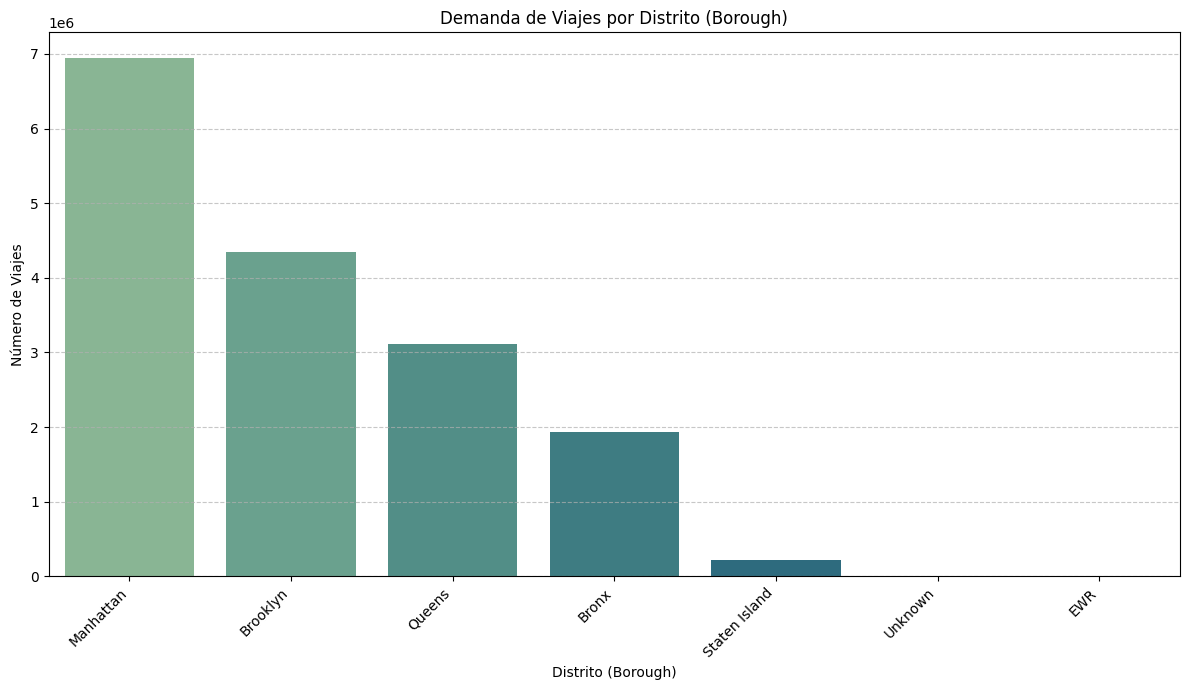

In [24]:
# 3. Convertir el resultado a Pandas DataFrame para visualización
demand_by_borough_pd = demand_by_borough_spark.toPandas()

plt.figure(figsize=(12, 7))
sns.barplot(x='Borough', y='count', data=demand_by_borough_pd, palette='crest', hue='Borough', legend=False)
plt.title('Demanda de Viajes por Distrito (Borough)')
plt.xlabel('Distrito (Borough)')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* **Observación:** Manhattan concentra la gran mayoría de la demanda, con un volumen que casi duplica al de Brooklyn. Distritos como Staten Island o EWR tienen una demanda marginal en comparación.

* **Insight de Negocio:** La infraestructura de transporte público en Manhattan es densa, pero la demanda de Uber sigue siendo masiva. Esto sugiere que los usuarios eligen Uber por conveniencia o rapidez ante el clima neoyorquino. En distritos como Brooklyn y Queens, donde las distancias son mayores, la sensibilidad al clima podría ser un factor crítico para la rentabilidad de los conductores.

## Conclusión Inicial: Dinámica de la Demanda de Transporte en NYC

El análisis de los viajes de taxi y HVFHS (Uber/Lyft) en NYC para octubre de 2021, junto con datos climáticos y geográficos, revela patrones claros en la demanda de transporte:

*   **Demanda Concentrada y de Corta Distancia**: La mayoría de los viajes son de distancias cortas (menos de 5 millas) y duraciones de 10-25 minutos, sugiriendo un uso para tramos internos complementarios al transporte público.
*   **Patrones Temporales Definidos**: La demanda presenta un "doble pico" con un fuerte y sostenido aumento entre las 2:00 PM y las 8:00 PM, indicando una preponderancia de viajes vespertinos/nocturnos (ocio, regreso a casa). La demanda es estable de lunes a jueves, pero se dispara significativamente los viernes y sábados, validando su uso para actividades sociales.
*   **Influencia del Clima**: Las condiciones climáticas tienen un impacto notable. Mientras que las temperaturas moderadas estabilizan la demanda, la lluvia genera picos impredecibles (activando tarifas dinámicas), y los días despejados muestran una demanda más alta y consistente en comparación con días de clima mixto.
*   **Distribución Geográfica Desigual**: Manhattan domina la demanda de viajes, casi duplicando a Brooklyn. Esto sugiere que, a pesar de una densa red de transporte público, los usuarios de Manhattan priorizan la conveniencia y rapidez. En contraste, los distritos exteriores podrían ser más sensibles al clima para la rentabilidad de los conductores.

En resumen, la demanda de transporte en NYC está fuertemente influenciada por la hora del día, el día de la semana y las condiciones climáticas, con un claro impacto geográfico. Estos insights son cruciales para optimizar la distribución de conductores y la implementación de estrategias de precios dinámicos por parte de las plataformas de movilidad.